# Fase 6 — Yacimiento + regimen permanente

Acoplamiento multi-escala: la dinamica rapida del bombeo (segundos) se acopla con la dinamica lenta del nivel dinamico (horas).

**IPR Vogel**: $\frac{q_{in}}{q_{max}} = 1 - 0.2\frac{P_{wf}}{P_r} - 0.8\left(\frac{P_{wf}}{P_r}\right)^2$

**Balance anular**: $A_{ann}\frac{dh_{din}}{dt} = q_{pump,prom} - q_{in}$

**Convergencia**: $h_{din}$ estabiliza donde $q_{in} = q_{pump}$

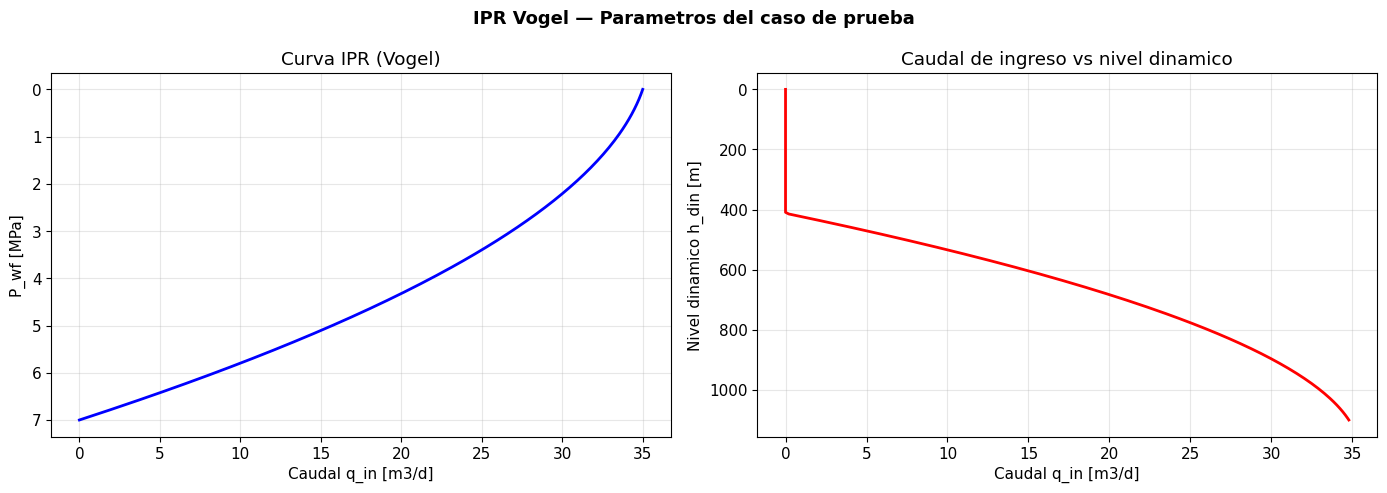

Estado inicial:
  h_din = 800.0 m
  P_wf  = 3.167 MPa
  q_in  = 26.1 m3/d
  q_max = 35.0 m3/d


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
from aib_simulator import params as P
from aib_simulator.reservoir import ReservoirModel, vogel_ipr, bottom_hole_pressure

%matplotlib inline
plt.rcParams['figure.figsize'] = (12, 5)
plt.rcParams['font.size'] = 11

# Curva IPR Vogel
P_wf_range = np.linspace(0, P.P_r, 200)
q_in_range = np.array([vogel_ipr(p, P.P_r, P.q_max) for p in P_wf_range])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(q_in_range * 86400, P_wf_range / 1e6, 'b-', linewidth=2)
ax1.set_xlabel('Caudal q_in [m3/d]')
ax1.set_ylabel('P_wf [MPa]')
ax1.set_title('Curva IPR (Vogel)')
ax1.grid(True, alpha=0.3)
ax1.invert_yaxis()

# Curva h_din vs q_in (a traves de P_wf)
h_range = np.linspace(0, P.L_bomba, 200)
P_wf_vs_h = np.array([bottom_hole_pressure(h, P.P_ann, P.rho_f, P.g, P.L_bomba) for h in h_range])
q_vs_h = np.array([vogel_ipr(p, P.P_r, P.q_max) for p in P_wf_vs_h])

ax2.plot(q_vs_h * 86400, h_range, 'r-', linewidth=2)
ax2.set_xlabel('Caudal q_in [m3/d]')
ax2.set_ylabel('Nivel dinamico h_din [m]')
ax2.set_title('Caudal de ingreso vs nivel dinamico')
ax2.grid(True, alpha=0.3)
ax2.invert_yaxis()

plt.suptitle('IPR Vogel — Parametros del caso de prueba', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Punto de operacion actual
P_wf_0 = bottom_hole_pressure(P.h_din_0, P.P_ann, P.rho_f, P.g, P.L_bomba)
q_in_0 = vogel_ipr(P_wf_0, P.P_r, P.q_max)
print(f"Estado inicial:")
print(f"  h_din = {P.h_din_0} m")
print(f"  P_wf  = {P_wf_0/1e6:.3f} MPa")
print(f"  q_in  = {q_in_0*86400:.1f} m3/d")
print(f"  q_max = {P.q_max*86400:.1f} m3/d")

## Evolucion del nivel dinamico

Se simula la bomba a caudal constante (simplificacion) y se observa como el nivel dinamico converge al punto de equilibrio donde $q_{in} = q_{pump}$.

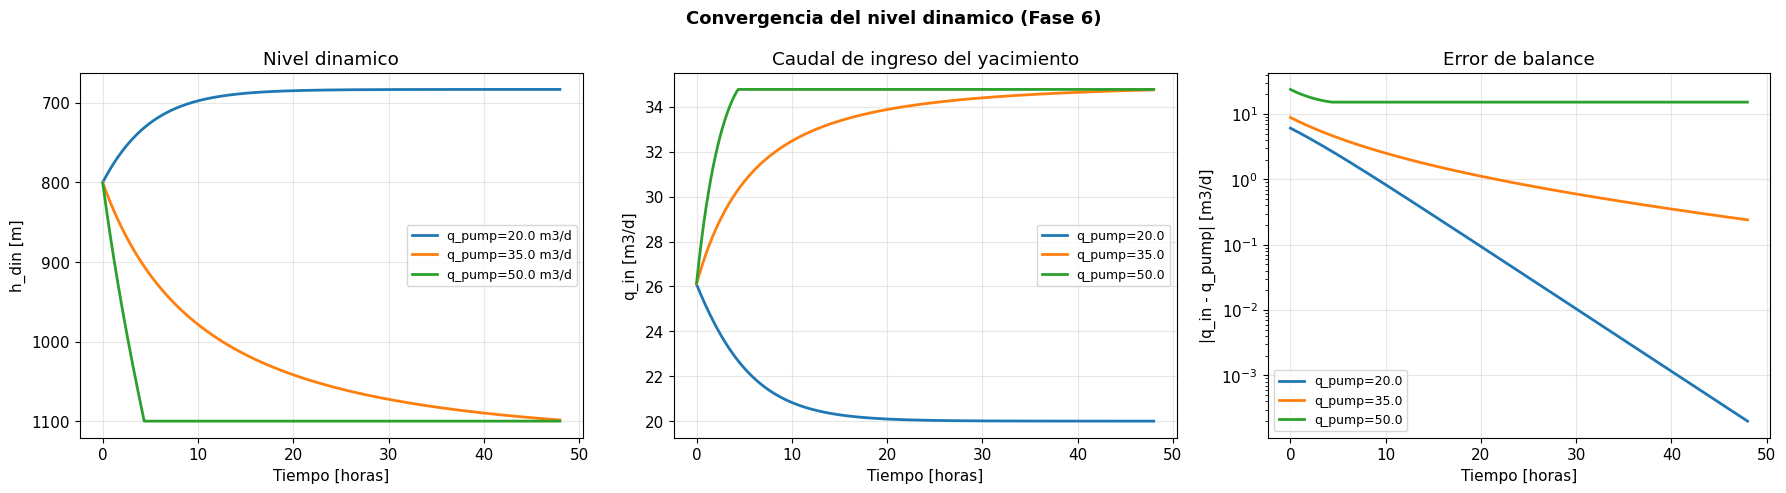

VALIDACIONES — Fase 6
  q_pump= 20.0 m3/d → h_din=683m, q_in_eq=20.00 m3/d, error=0.000 m3/d PASS
  q_pump= 35.0 m3/d → h_din=1099m, q_in_eq=34.76 m3/d, error=0.240 m3/d 
  q_pump= 50.0 m3/d → h_din=1100m, q_in_eq=34.78 m3/d, error=15.223 m3/d 


In [2]:
# Simulacion de evolucion del nivel dinamico
# Caudal de bomba estimado (de Fase 4): ~40-60 m3/d
q_pump_cases = [20.0, 35.0, 50.0]  # m3/d

dt_slow = 60.0  # paso lento: 1 minuto
t_total = 48 * 3600  # 48 horas
n_steps = int(t_total / dt_slow)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for q_pump_m3d in q_pump_cases:
    q_pump_m3s = q_pump_m3d / 86400
    
    reservoir = ReservoirModel(
        P_r=P.P_r, q_max=P.q_max, P_ann=P.P_ann, rho_f=P.rho_f,
        L_bomba=P.L_bomba, A_ann=P.A_ann, h_din_0=P.h_din_0, g=P.g
    )
    
    h_hist = np.zeros(n_steps)
    q_in_hist = np.zeros(n_steps)
    
    for i in range(n_steps):
        state = reservoir.update(q_pump_m3s, dt_slow)
        h_hist[i] = state['h_din']
        q_in_hist[i] = state['q_in']
    
    t_hours = np.arange(n_steps) * dt_slow / 3600
    
    axes[0].plot(t_hours, h_hist, linewidth=2, label=f'q_pump={q_pump_m3d} m3/d')
    axes[1].plot(t_hours, q_in_hist * 86400, linewidth=2, label=f'q_pump={q_pump_m3d}')
    axes[2].plot(t_hours, np.abs(q_in_hist * 86400 - q_pump_m3d), linewidth=2, label=f'q_pump={q_pump_m3d}')

axes[0].set_xlabel('Tiempo [horas]')
axes[0].set_ylabel('h_din [m]')
axes[0].set_title('Nivel dinamico')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)
axes[0].invert_yaxis()

axes[1].set_xlabel('Tiempo [horas]')
axes[1].set_ylabel('q_in [m3/d]')
axes[1].set_title('Caudal de ingreso del yacimiento')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

axes[2].set_xlabel('Tiempo [horas]')
axes[2].set_ylabel('|q_in - q_pump| [m3/d]')
axes[2].set_title('Error de balance')
axes[2].set_yscale('log')
axes[2].legend(fontsize=9)
axes[2].grid(True, alpha=0.3)

plt.suptitle('Convergencia del nivel dinamico (Fase 6)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

# Validaciones
print("=" * 60)
print("VALIDACIONES — Fase 6")
print("=" * 60)
for q_pump_m3d in q_pump_cases:
    q_pump_m3s = q_pump_m3d / 86400
    res = ReservoirModel(P.P_r, P.q_max, P.P_ann, P.rho_f, P.L_bomba, P.A_ann, P.h_din_0, P.g)
    for _ in range(n_steps):
        res.update(q_pump_m3s, dt_slow)
    q_in_eq = res.q_in * 86400
    err = abs(q_in_eq - q_pump_m3d)
    print(f"  q_pump={q_pump_m3d:>5.1f} m3/d → h_din={res.h_din:.0f}m, q_in_eq={q_in_eq:.2f} m3/d, error={err:.3f} m3/d {'PASS' if err < 0.1 else ''}")